# 분류 SHAP–군집 lift 교차해석

## tl;dr

`Full-LightGBM`의 원 피처 SHAP 중요도와 기존 전체변수 군집 lift를
**새로 학습하거나 재계산하지 않고** 연결한다. SHAP은 CASE 1·CASE 2
분류에 기여한 정도이고, lift는 같은 여행층 안에서 군집의 상대적 특징이다.
따라서 결과는 연관성과 내부 유형 차이만 보여 주며, 정책의 인과효과나
출생지·법적 고향을 뜻하지 않는다.

- 주 결과: 비교 가능한 피처별 중앙값 기준 4분면
- 민감도: SHAP 상위 20개와 `lift ≥ 1.5 또는 ≤ 0.67` 표시 기준
- 분석 단위: 저장된 군집 lift 표의 여행층·군집·피처 수준. 가중 분모와
  표본 수는 원 군집 분석 결과를 그대로 사용한다.
- 범위: 변환 피처가 아닌 `original_feature` SHAP만 사용한다. 정의가 다른
  파생 피처, 숙박 직접신호, 사전층화 변수, 방문시도 더미와 분모가 다른
  상세 소비 피처는 억지로 결합하지 않고 감사표에 사유를 남긴다.

In [32]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("프로젝트 루트의 src 폴더를 찾지 못했습니다.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text

from src.path import OUTPUTS_DIR, create_output_directories
from src.visualization import COLORS, apply_plot_style

apply_plot_style()

NOTEBOOK_NAME = "260726_분류_SHAP_군집_lift_교차해석.ipynb"
CLASSIFICATION_OUTPUT = "260726_CASE1_CASE2_분류모형_260725_2038"
CLUSTER_OUTPUT = "260726_연고관광_전체변수_클러스터_lift_260726_0814"
CLASSIFICATION_TABLES = OUTPUTS_DIR / CLASSIFICATION_OUTPUT / "tables"
CLUSTER_LIFT_PATH = (
    OUTPUTS_DIR
    / CLUSTER_OUTPUT
    / "tables"
    / "cluster_lift_all_variables.csv"
)
LEADERBOARD_PATH = CLASSIFICATION_TABLES / "validation_leaderboard.csv"
SHAP_DOMAIN_PATH = CLASSIFICATION_TABLES / "full_lightgbm_shap_domains.csv"
SHAP_FEATURE_PATH = (
    CLASSIFICATION_TABLES / "full_lightgbm_shap_original_features.csv"
)
FIGURES_DIR, TABLES_DIR = create_output_directories(NOTEBOOK_NAME)

MIN_CLUSTER_N = 30
MIN_CATEGORY_SHARE = 0.01
MIN_CATEGORY_LEVEL_N = 30
FIXED_LIFT_HIGH = 1.5
FIXED_LIFT_LOW = 0.67
TOP_SHAP_FEATURES = 20

VALIDATED_ALIASES = {
    "age_group": ["BAGE"],
    "household_income_band": ["BINC1"],
    "household_size": ["BFAM"],
    "marital_status": ["BMAR"],
    "party_size_band": ["party_group"],
    "with_friend": ["A6B_3"],
    "with_family_relative": ["A6B_1", "A6B_2"],
    "share_a8f": ["share_transport"],
    "spent_a8g": ["activity_spend"],
}
DEFINITION_MISMATCHES = {
    "activity_group_count": "활동 대분류 집계 정의가 원변수와 다릅니다.",
    "reservation_count": "예약 횟수 집계 정의가 원변수와 다릅니다.",
}
EXCLUDED_CLUSTER_FEATURES = {
    "has_lodging_12": (
        "family_home_lodging과 정의상 연결되지만 군집 lift 표에서 제외됐습니다."
    ),
}

## 입력 경로와 최적모형 확인

아래 네 파일만 읽는다. leaderboard의 F1 내림차순 최상단이
`Full-LightGBM`인지 확인한 뒤, 해당 모형의 저장된 SHAP 표만 쓴다.

In [33]:
for path in [
    LEADERBOARD_PATH,
    SHAP_DOMAIN_PATH,
    SHAP_FEATURE_PATH,
    CLUSTER_LIFT_PATH,
]:
    assert path.is_file(), f"입력 파일이 없습니다: {path}"

leaderboard = pd.read_csv(LEADERBOARD_PATH, encoding="utf-8-sig")
shap_domains = pd.read_csv(SHAP_DOMAIN_PATH, encoding="utf-8-sig")
shap_features = pd.read_csv(SHAP_FEATURE_PATH, encoding="utf-8-sig")
lift_all = pd.read_csv(CLUSTER_LIFT_PATH, encoding="utf-8-sig")

leaderboard = leaderboard.sort_values("f1", ascending=False).reset_index(
    drop=True
)
best_model = leaderboard.iloc[0]
assert (
    best_model["tier"] == "Full"
    and best_model["model"] == "lightgbm"
), "저장된 leaderboard의 최상위 모형이 Full-LightGBM이 아닙니다."

print(
    "확인된 최적모형: Full-LightGBM "
    f"(F1={best_model['f1']:.4f}, PR-AUC={best_model['pr_auc']:.4f})"
)
display(leaderboard.head(8))

확인된 최적모형: Full-LightGBM (F1=0.6878, PR-AUC=0.7299)


,tier,model,threshold,f1,precision,recall,pr_auc,roc_auc
0,Full,lightgbm,0.615,0.687812,0.788022,0.610214,0.729890,0.873743
1,Full,xgboost,0.350,0.684148,0.798887,0.598228,0.729496,0.871261
2,Full,catboost,0.580,0.680382,0.766319,0.611777,0.729926,0.872404
3,Full,random_forest,0.505,0.651136,0.737954,0.582595,0.698927,0.858178
4,Base,xgboost,0.280,0.648679,0.712859,0.595102,0.699125,0.852390
5,Base,lightgbm,0.640,0.647921,0.760534,0.564356,0.697295,0.852821
6,Base,catboost,0.610,0.643314,0.774194,0.550287,0.686860,0.846160
7,Base,random_forest,0.445,0.633846,0.684179,0.590412,0.686615,0.848211


## SHAP·lift 스키마와 분석 단위 검증

군집 lift의 `층`은 당일·숙박여행을 분리한 비교 기준이다. 대표 수준은
유효한 양의 lift, 군집 셀 비가중 N 30 이상을 기본으로 하며, 범주형은
층 내 가중 비율 1% 이상과 수준 비가중 N 30 이상도 요구한다. 희소 수준은
감사용 입력에는 보존하지만 대표 근거와 결론에서는 제외한다.

In [34]:
required_shap_columns = {
    "original_feature",
    "mean_abs_shap",
    "mean_shap",
    "domain",
    "direction",
}
required_lift_columns = {
    "층",
    "군집",
    "변수 유형",
    "변수",
    "변수 라벨",
    "수준 코드",
    "수준 라벨",
    "표시 특징",
    "군집 셀 비가중 N",
    "수준 비가중 N",
    "가중 분모",
    "군집값",
    "층 기준값",
    "층 내 가중 비율",
    "lift",
    "log2(lift)",
    "lift 미산출 사유",
    "실질 수준 여부",
}
assert not (required_shap_columns - set(shap_features.columns))
assert not (required_lift_columns - set(lift_all.columns))
assert shap_features["original_feature"].is_unique
assert lift_all["가중 분모"].dropna().gt(0).all()
assert lift_all["군집 셀 비가중 N"].dropna().ge(0).all()
assert lift_all["층 내 가중 비율"].dropna().between(0, 1).all()

lift_key = ["층", "군집", "변수", "수준 코드"]
assert not lift_all.duplicated(lift_key).any(), "군집 lift 키가 중복됩니다."

lift_all["실질 수준 여부"] = lift_all["실질 수준 여부"].astype(bool)
category_mask = lift_all["변수 유형"].eq("범주형")
candidate_mask = (
    lift_all["군집 셀 비가중 N"].ge(MIN_CLUSTER_N)
    & lift_all["실질 수준 여부"]
    & lift_all["lift"].gt(0)
    & lift_all["log2(lift)"].notna()
    & lift_all["lift 미산출 사유"].isna()
    & (
        ~category_mask
        | (
            lift_all["층 내 가중 비율"].ge(MIN_CATEGORY_SHARE)
            & lift_all["수준 비가중 N"].ge(MIN_CATEGORY_LEVEL_N)
        )
    )
)
lift_candidates = lift_all.loc[candidate_mask].copy()

print(
    f"원 lift 행 {len(lift_all):,}개 중 대표 수준 후보 "
    f"{len(lift_candidates):,}개"
)
display(shap_features.head(10))
display(lift_candidates.head(5))

원 lift 행 4,136개 중 대표 수준 후보 2,271개


,original_feature,mean_abs_shap,mean_shap,domain,direction
0,has_lodging_12,0.564684,-0.010421,숙박,CASE 1
1,family_home_only,0.163702,-0.007013,동반,CASE 1
2,activity_group_count,0.150006,-0.000953,활동,CASE 1
3,information_online,0.121175,0.005296,정보,CASE 2
4,A5_1,0.115735,-0.003110,정보,CASE 1
5,lodging_summary,0.095832,-0.006882,숙박,CASE 1
6,spend_per_person_day,0.094414,0.014334,소비,CASE 2
7,share_a8f,0.094063,0.011387,소비,CASE 2
8,A3_RANKW_2,0.094030,0.000698,기타,CASE 2
9,with_friend,0.091238,-0.010476,동반,CASE 1


,층,군집,변수 유형,변수,변수 라벨,수준 코드,수준 라벨,표시 특징,군집 셀 비가중 N,유효 비가중 N,...,결측 N,가중 분모,군집값,층 기준값,가중평균 차이,층 내 가중 비율,lift,log2(lift),lift 미산출 사유,실질 수준 여부
0,당일여행,당일여행 C1,범주형,YEAR,조사연도,2023,2023년,조사연도 — 2023: 2023년,677,677,...,0,6.700951e+06,0.348531,0.363849,-0.015318,0.363849,0.957901,-0.062052,NaN,True
1,당일여행,당일여행 C1,범주형,YEAR,조사연도,2024,2024년,조사연도 — 2024: 2024년,677,677,...,0,6.700951e+06,0.410655,0.387997,0.022658,0.387997,1.058398,0.081882,NaN,True
2,당일여행,당일여행 C1,범주형,YEAR,조사연도,2025,2025년,조사연도 — 2025: 2025년,677,677,...,0,6.700951e+06,0.240814,0.248154,-0.007340,0.248154,0.970420,-0.043319,NaN,True
3,당일여행,당일여행 C2,범주형,YEAR,조사연도,2023,2023년,조사연도 — 2023: 2023년,5033,5033,...,0,4.952222e+07,0.365921,0.363849,0.002073,0.363849,1.005697,0.008195,NaN,True
4,당일여행,당일여행 C2,범주형,YEAR,조사연도,2024,2024년,조사연도 — 2024: 2024년,5033,5033,...,0,4.952222e+07,0.384931,0.387997,-0.003066,0.387997,0.992098,-0.011445,NaN,True


## 변수 정의 매칭 감사

감사표는 SHAP 원 피처 한 행당 하나의 분류만 부여한다. 1:N 검증 별칭은
이 표에서 세미콜론으로 보관해 행을 증폭하지 않는다. 이후 근거 산출에서만
연결된 군집 변수를 비교하고, 가장 큰 절대 `log2(lift)` 행 하나를 대표로
선택한다.

In [35]:
def mapping_record(feature: str, lift_variables: set[str]) -> dict[str, str]:
    """SHAP 원 피처의 군집 lift 연결 상태를 한 행으로 정리한다.

    Args:
        feature: Full-LightGBM의 원 피처 이름이다.
        lift_variables: 군집 lift 표에 있는 변수명 집합이다.

    Returns:
        연결 상태, 대상 변수와 비교 불가 사유를 담은 딕셔너리다.
    """
    if feature in EXCLUDED_CLUSTER_FEATURES:
        return {
            "매칭 분류": "군집표 제외",
            "연결 군집 변수": "family_home_lodging",
            "감사 사유": EXCLUDED_CLUSTER_FEATURES[feature],
        }
    if feature in DEFINITION_MISMATCHES:
        return {
            "매칭 분류": "정의 불일치",
            "연결 군집 변수": "",
            "감사 사유": DEFINITION_MISMATCHES[feature],
        }
    if feature in VALIDATED_ALIASES:
        return {
            "매칭 분류": "검증 별칭",
            "연결 군집 변수": ";".join(VALIDATED_ALIASES[feature]),
            "감사 사유": "변수 정의를 대조한 검증 별칭입니다.",
        }
    if feature in lift_variables:
        return {
            "매칭 분류": "정의 일치",
            "연결 군집 변수": feature,
            "감사 사유": "원변수와 정의가 같은 군집 lift 변수입니다.",
        }

    if feature.startswith("visit_sido_"):
        reason = "방문시도 더미는 군집표의 원 방문지 변수와 직접 비교할 수 없습니다."
    elif feature.startswith(("share_", "amount_", "spent_")):
        reason = "분모 또는 소비 항목이 다른 상세 소비 파생 피처입니다."
    elif feature.startswith(("has_lodging_", "reserved_lodging")):
        reason = "숙박 직접신호는 군집표의 별도 정의와 직접 비교할 수 없습니다."
    elif feature in {"overnight_type", "season", "includes_holiday", "includes_weekend", "includes_weekday"}:
        reason = "사전층화 또는 일정 파생 변수로 군집 lift의 직접 비교 대상이 아닙니다."
    else:
        reason = "군집 lift 표에 정의가 같은 변수가 없어 비교할 수 없습니다."
    return {
        "매칭 분류": "미매칭",
        "연결 군집 변수": "",
        "감사 사유": reason,
    }


lift_variable_set = set(lift_all["변수"].astype(str))
feature_mapping_audit = shap_features.copy()
audit_details = feature_mapping_audit["original_feature"].map(
    lambda feature: mapping_record(feature, lift_variable_set)
)
audit_details = pd.DataFrame(audit_details.tolist())
feature_mapping_audit = pd.concat(
    [feature_mapping_audit.reset_index(drop=True), audit_details],
    axis=1,
)
feature_mapping_audit["SHAP 순위"] = (
    feature_mapping_audit["mean_abs_shap"]
    .rank(method="first", ascending=False)
    .astype(int)
)
feature_mapping_audit = feature_mapping_audit.sort_values("SHAP 순위")

valid_mapping_categories = {
    "정의 일치",
    "검증 별칭",
    "정의 불일치",
    "군집표 제외",
    "미매칭",
}
assert feature_mapping_audit["original_feature"].is_unique
assert set(feature_mapping_audit["매칭 분류"]).issubset(
    valid_mapping_categories
)
assert len(feature_mapping_audit) == len(shap_features)
assert not feature_mapping_audit["매칭 분류"].isna().any()

feature_mapping_audit.to_csv(
    TABLES_DIR / "feature_mapping_audit.csv",
    index=False,
    encoding="utf-8-sig",
)
display(feature_mapping_audit["매칭 분류"].value_counts().rename("피처 수"))
display(feature_mapping_audit.head(20))

매칭 분류
미매칭       202
정의 일치      85
검증 별칭       9
정의 불일치      2
군집표 제외      1
Name: 피처 수, dtype: int64

,original_feature,mean_abs_shap,mean_shap,domain,direction,매칭 분류,연결 군집 변수,감사 사유,SHAP 순위
0,has_lodging_12,0.564684,-0.010421,숙박,CASE 1,군집표 제외,family_home_lodging,family_home_lodging과 정의상 연결되지만 군집 lift 표에서 제외됐...,1
1,family_home_only,0.163702,-0.007013,동반,CASE 1,미매칭,,군집 lift 표에 정의가 같은 변수가 없어 비교할 수 없습니다.,2
2,activity_group_count,0.150006,-0.000953,활동,CASE 1,정의 불일치,,활동 대분류 집계 정의가 원변수와 다릅니다.,3
3,information_online,0.121175,0.005296,정보,CASE 2,정의 일치,information_online,원변수와 정의가 같은 군집 lift 변수입니다.,4
4,A5_1,0.115735,-0.003110,정보,CASE 1,정의 일치,A5_1,원변수와 정의가 같은 군집 lift 변수입니다.,5
5,lodging_summary,0.095832,-0.006882,숙박,CASE 1,미매칭,,군집 lift 표에 정의가 같은 변수가 없어 비교할 수 없습니다.,6
6,spend_per_person_day,0.094414,0.014334,소비,CASE 2,정의 일치,spend_per_person_day,원변수와 정의가 같은 군집 lift 변수입니다.,7
7,share_a8f,0.094063,0.011387,소비,CASE 2,검증 별칭,share_transport,변수 정의를 대조한 검증 별칭입니다.,8
8,A3_RANKW_2,0.094030,0.000698,기타,CASE 2,정의 일치,A3_RANKW_2,원변수와 정의가 같은 군집 lift 변수입니다.,9
9,with_friend,0.091238,-0.010476,동반,CASE 1,검증 별칭,A6B_3,변수 정의를 대조한 검증 별칭입니다.,10


## 개별 피처 교차근거표

비교 가능한 피처마다 여행층별 대표 군집 차이를 계산한다. `대표 lift`가
1보다 크거나 작다는 것은 해당 군집이 **그 층 평균 대비** 해당 수준을
과대표·과소대표한다는 뜻이며, CASE 분류의 인과적 설명은 아니다.

In [36]:
comparable = feature_mapping_audit.loc[
    feature_mapping_audit["매칭 분류"].isin(["정의 일치", "검증 별칭"])
].copy()
comparable["연결 변수 목록"] = comparable["연결 군집 변수"].str.split(";")
expanded_mapping = comparable.explode("연결 변수 목록").rename(
    columns={"연결 변수 목록": "연결 변수"}
)
assert len(expanded_mapping) >= len(comparable)
assert comparable["original_feature"].is_unique
repeated_targets = set(
    expanded_mapping.loc[
        expanded_mapping.duplicated("연결 변수", keep=False), "연결 변수"
    ]
)
assert repeated_targets.issubset({"A6B_1", "A6B_2", "A6B_3"})

representative_pool = expanded_mapping.merge(
    lift_candidates,
    left_on="연결 변수",
    right_on="변수",
    how="left",
    validate="many_to_many",
)
representative_pool["절대 log2(lift)"] = representative_pool[
    "log2(lift)"
].abs()
representative_pool = representative_pool.sort_values(
    [
        "original_feature",
        "층",
        "절대 log2(lift)",
        "연결 변수",
        "군집",
        "수준 코드",
    ],
    ascending=[True, True, False, True, True, True],
)
representative = representative_pool.drop_duplicates(
    ["original_feature", "층"], keep="first"
).copy()

all_feature_strata = pd.MultiIndex.from_product(
    [
        feature_mapping_audit["original_feature"],
        sorted(lift_all["층"].dropna().unique()),
    ],
    names=["original_feature", "층"],
).to_frame(index=False)
cross_feature_evidence = all_feature_strata.merge(
    feature_mapping_audit,
    on="original_feature",
    how="left",
    validate="many_to_one",
).merge(
    representative[
        [
            "original_feature",
            "층",
            "연결 변수",
            "군집",
            "변수 라벨",
            "수준 코드",
            "수준 라벨",
            "표시 특징",
            "군집 셀 비가중 N",
            "수준 비가중 N",
            "가중 분모",
            "군집값",
            "층 기준값",
            "층 내 가중 비율",
            "lift",
            "log2(lift)",
            "절대 log2(lift)",
        ]
    ],
    on=["original_feature", "층"],
    how="left",
    validate="one_to_one",
)
cross_feature_evidence = cross_feature_evidence.rename(
    columns={
        "연결 변수": "대표 군집 변수",
        "군집": "대표 군집",
        "변수 라벨": "대표 변수 라벨",
        "수준 코드": "대표 수준 코드",
        "수준 라벨": "대표 수준 라벨",
        "표시 특징": "대표 표시 특징",
        "군집 셀 비가중 N": "대표 군집 셀 비가중 N",
        "수준 비가중 N": "대표 수준 비가중 N",
        "가중 분모": "대표 가중 분모",
        "군집값": "대표 군집값",
        "층 기준값": "대표 층 기준값",
        "lift": "대표 lift",
        "log2(lift)": "대표 log2(lift)",
        "절대 log2(lift)": "최대 lift 편차",
    }
)
cross_feature_evidence["비교 가능"] = cross_feature_evidence[
    "최대 lift 편차"
].notna()
cross_feature_evidence = cross_feature_evidence.sort_values(
    ["층", "SHAP 순위"]
)
assert not cross_feature_evidence.duplicated(
    ["original_feature", "층"]
).any()

cross_feature_evidence.to_csv(
    TABLES_DIR / "cross_feature_evidence.csv",
    index=False,
    encoding="utf-8-sig",
)
display(cross_feature_evidence.loc[
    cross_feature_evidence["비교 가능"]
].head(20))

,original_feature,층,mean_abs_shap,mean_shap,domain,direction,매칭 분류,연결 군집 변수,감사 사유,SHAP 순위,...,대표 군집 셀 비가중 N,대표 수준 비가중 N,대표 가중 분모,대표 군집값,대표 층 기준값,층 내 가중 비율,대표 lift,대표 log2(lift),최대 lift 편차,비교 가능
6,information_online,당일여행,0.121175,0.005296,정보,CASE 2,정의 일치,information_online,원변수와 정의가 같은 군집 lift 변수입니다.,4,...,677.0,120.0,6.700951e+06,0.221462,0.125765,0.125765,1.760924,0.816332,0.816332,True
8,A5_1,당일여행,0.115735,-0.003110,정보,CASE 1,정의 일치,A5_1,원변수와 정의가 같은 군집 lift 변수입니다.,5,...,677.0,98.0,6.700951e+06,0.126508,0.214878,0.214878,0.588741,-0.764294,0.764294,True
12,spend_per_person_day,당일여행,0.094414,0.014334,소비,CASE 2,정의 일치,spend_per_person_day,원변수와 정의가 같은 군집 lift 변수입니다.,7,...,677.0,677.0,6.700951e+06,72707.740924,66287.385934,NaN,1.096856,0.133375,0.133375,True
14,share_a8f,당일여행,0.094063,0.011387,소비,CASE 2,검증 별칭,share_transport,변수 정의를 대조한 검증 별칭입니다.,8,...,677.0,677.0,6.700951e+06,0.209879,0.270791,NaN,0.775058,-0.367624,0.367624,True
16,A3_RANKW_2,당일여행,0.094030,0.000698,기타,CASE 2,정의 일치,A3_RANKW_2,원변수와 정의가 같은 군집 lift 변수입니다.,9,...,677.0,677.0,6.700951e+06,0.827804,0.657107,NaN,1.259771,0.333161,0.333161,True
18,with_friend,당일여행,0.091238,-0.010476,동반,CASE 1,검증 별칭,A6B_3,변수 정의를 대조한 검증 별칭입니다.,10,...,677.0,189.0,6.700951e+06,0.308488,0.250359,0.250359,1.232182,0.301215,0.301215,True
24,age_group,당일여행,0.087761,-0.005735,여행자,CASE 1,검증 별칭,BAGE,변수 정의를 대조한 검증 별칭입니다.,13,...,677.0,61.0,6.700951e+06,0.075353,0.114634,0.114634,0.657336,-0.605297,0.605297,True
28,A4_1,당일여행,0.082372,-0.008464,활동,CASE 1,정의 일치,A4_1,원변수와 정의가 같은 군집 lift 변수입니다.,15,...,677.0,262.0,6.700951e+06,0.400384,0.351384,0.351384,1.139447,0.188334,0.188334,True
30,A3_RANKW_1,당일여행,0.081918,0.000843,기타,CASE 2,정의 일치,A3_RANKW_1,원변수와 정의가 같은 군집 lift 변수입니다.,16,...,677.0,677.0,6.700951e+06,0.820042,0.684405,NaN,1.198183,0.260848,0.260848,True
32,with_family_relative,당일여행,0.069519,-0.004490,동반,CASE 1,검증 별칭,A6B_1;A6B_2,변수 정의를 대조한 검증 별칭입니다.,17,...,677.0,231.0,6.700951e+06,0.359701,0.322509,0.322509,1.115321,0.157459,0.157459,True


## 중앙값 4분면과 고정 기준 민감도

주 결과는 각 여행층의 비교 가능한 피처에서 SHAP 중요도와 최대 lift 편차의
중앙값을 기준으로 한다. 민감도 결과의 고정 기준은 `SHAP 상위 20개` 및
`lift ≥ 1.5 또는 ≤ 0.67`이며, 통계적 유의성 검정이 아닌 실무적 표시
기준이다.

In [37]:
def assign_quadrant(
    high_shap: pd.Series,
    high_lift: pd.Series,
) -> np.ndarray:
    """두 이진 기준을 해석용 4분면 이름으로 바꾼다.

    Args:
        high_shap: SHAP 중요도가 기준 이상인지 나타내는 불리언 열이다.
        high_lift: 군집 lift 편차가 기준 이상인지 나타내는 불리언 열이다.

    Returns:
        각 행의 4분면 이름 배열이다.
    """
    return np.select(
        [
            high_shap & high_lift,
            high_shap & ~high_lift,
            ~high_shap & high_lift,
        ],
        [
            "높은 분류 중요도·큰 군집 차이",
            "높은 분류 중요도·작은 군집 차이",
            "낮은 분류 중요도·큰 군집 차이",
        ],
        default="낮은 분류 중요도·작은 군집 차이",
    )


quadrant_frame = cross_feature_evidence.loc[
    cross_feature_evidence["비교 가능"]
].copy()
quadrant_frame["SHAP 상위 20개 여부"] = quadrant_frame["SHAP 순위"].le(
    TOP_SHAP_FEATURES
)
median_thresholds = (
    quadrant_frame.groupby("층", observed=True)
    .agg(
        중앙값_SHAP=("mean_abs_shap", "median"),
        중앙값_lift_편차=("최대 lift 편차", "median"),
    )
    .reset_index()
)
quadrant_frame = quadrant_frame.merge(
    median_thresholds,
    on="층",
    how="left",
    validate="many_to_one",
)
quadrant_frame["중앙값 기준 4분면"] = assign_quadrant(
    quadrant_frame["mean_abs_shap"].ge(quadrant_frame["중앙값_SHAP"]),
    quadrant_frame["최대 lift 편차"].ge(
        quadrant_frame["중앙값_lift_편차"]
    ),
)
quadrant_frame["고정 기준 lift 충족"] = (
    quadrant_frame["대표 lift"].ge(FIXED_LIFT_HIGH)
    | quadrant_frame["대표 lift"].le(FIXED_LIFT_LOW)
)
quadrant_frame["고정 기준 4분면"] = assign_quadrant(
    quadrant_frame["SHAP 상위 20개 여부"],
    quadrant_frame["고정 기준 lift 충족"],
)
quadrant_frame["유형 일치 여부"] = (
    quadrant_frame["중앙값 기준 4분면"]
    == quadrant_frame["고정 기준 4분면"]
)
quadrant_rule_comparison = quadrant_frame.sort_values(
    ["층", "SHAP 순위"]
)
quadrant_rule_comparison.to_csv(
    TABLES_DIR / "quadrant_rule_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

print("여행층별 중앙값 기준")
display(median_thresholds)
print("기준 변경으로 유형이 바뀐 피처")
display(quadrant_rule_comparison.loc[
    ~quadrant_rule_comparison["유형 일치 여부"]
])

여행층별 중앙값 기준


,층,중앙값_SHAP,중앙값_lift_편차
0,당일여행,0.008605,0.190746
1,숙박여행,0.008605,0.530148


기준 변경으로 유형이 바뀐 피처


,original_feature,층,mean_abs_shap,mean_shap,domain,direction,매칭 분류,연결 군집 변수,감사 사유,SHAP 순위,...,대표 log2(lift),최대 lift 편차,비교 가능,SHAP 상위 20개 여부,중앙값_SHAP,중앙값_lift_편차,중앙값 기준 4분면,고정 기준 lift 충족,고정 기준 4분면,유형 일치 여부
3,share_a8f,당일여행,0.094063,0.011387,소비,CASE 2,검증 별칭,share_transport,변수 정의를 대조한 검증 별칭입니다.,8,...,-0.367624,0.367624,True,True,0.008605,0.190746,높은 분류 중요도·큰 군집 차이,False,높은 분류 중요도·작은 군집 차이,False
4,A3_RANKW_2,당일여행,0.094030,0.000698,기타,CASE 2,정의 일치,A3_RANKW_2,원변수와 정의가 같은 군집 lift 변수입니다.,9,...,0.333161,0.333161,True,True,0.008605,0.190746,높은 분류 중요도·큰 군집 차이,False,높은 분류 중요도·작은 군집 차이,False
5,with_friend,당일여행,0.091238,-0.010476,동반,CASE 1,검증 별칭,A6B_3,변수 정의를 대조한 검증 별칭입니다.,10,...,0.301215,0.301215,True,True,0.008605,0.190746,높은 분류 중요도·큰 군집 차이,False,높은 분류 중요도·작은 군집 차이,False
8,A3_RANKW_1,당일여행,0.081918,0.000843,기타,CASE 2,정의 일치,A3_RANKW_1,원변수와 정의가 같은 군집 lift 변수입니다.,16,...,0.260848,0.260848,True,True,0.008605,0.190746,높은 분류 중요도·큰 군집 차이,False,높은 분류 중요도·작은 군집 차이,False
10,A3_2,당일여행,0.066863,0.001965,기타,CASE 2,정의 일치,A3_2,원변수와 정의가 같은 군집 lift 변수입니다.,19,...,0.398249,0.398249,True,True,0.008605,0.190746,높은 분류 중요도·큰 군집 차이,False,높은 분류 중요도·작은 군집 차이,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,A3_RANKW_3,숙박여행,0.010718,-0.000776,기타,CASE 1,정의 일치,A3_RANKW_3,원변수와 정의가 같은 군집 lift 변수입니다.,101,...,-0.411529,0.411529,True,False,0.008605,0.530148,높은 분류 중요도·작은 군집 차이,False,낮은 분류 중요도·작은 군집 차이,False
134,A3_RANKW_7,숙박여행,0.010524,0.000887,기타,CASE 2,정의 일치,A3_RANKW_7,원변수와 정의가 같은 군집 lift 변수입니다.,102,...,0.905824,0.905824,True,False,0.008605,0.530148,높은 분류 중요도·큰 군집 차이,True,낮은 분류 중요도·큰 군집 차이,False
135,A6B_4,숙박여행,0.009453,0.000125,동반,CASE 2,정의 일치,A6B_4,원변수와 정의가 같은 군집 lift 변수입니다.,107,...,-0.004731,0.004731,True,False,0.008605,0.530148,높은 분류 중요도·작은 군집 차이,False,낮은 분류 중요도·작은 군집 차이,False
136,A5A_2,숙박여행,0.009385,-0.000676,정보,CASE 1,정의 일치,A5A_2,원변수와 정의가 같은 군집 lift 변수입니다.,108,...,-0.166327,0.166327,True,False,0.008605,0.530148,높은 분류 중요도·작은 군집 차이,False,낮은 분류 중요도·작은 군집 차이,False


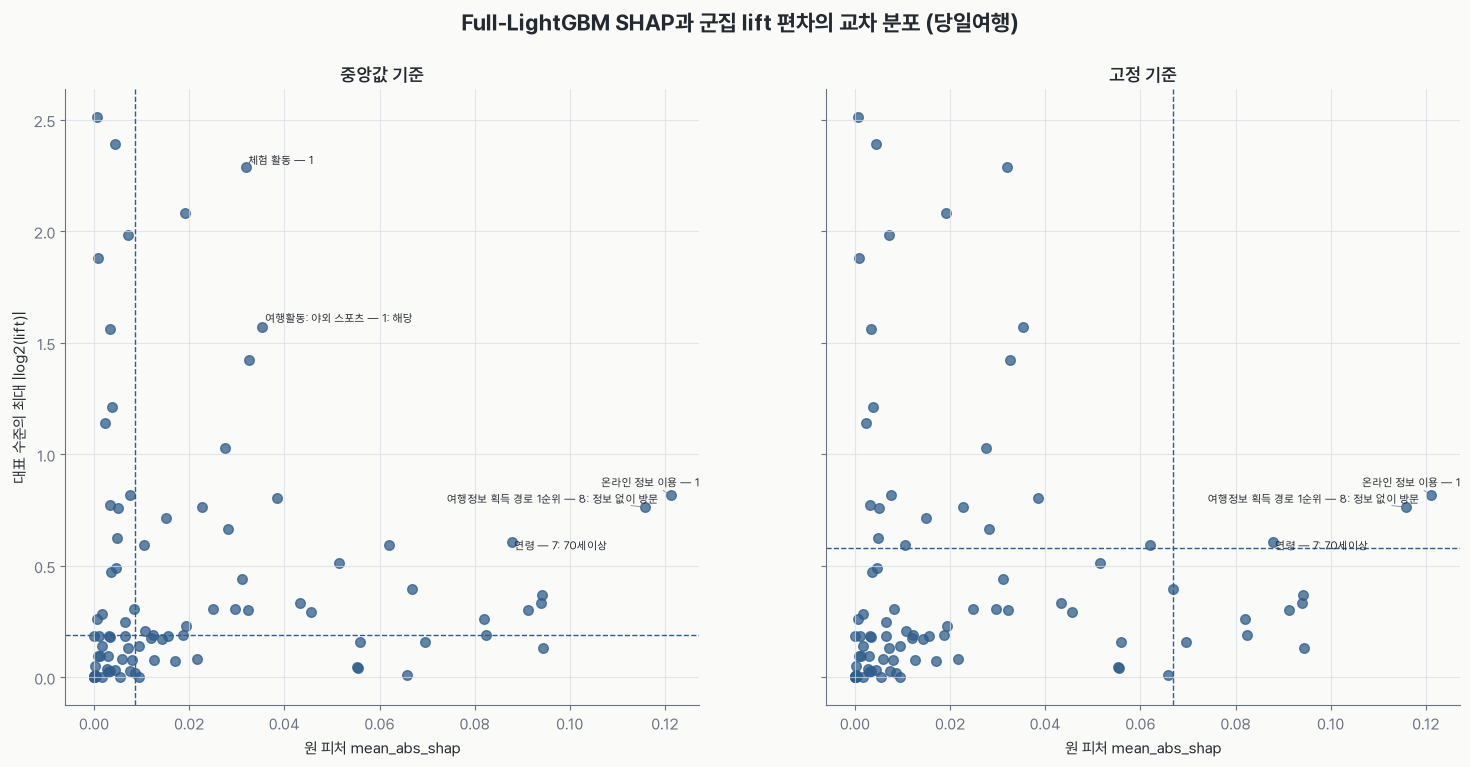

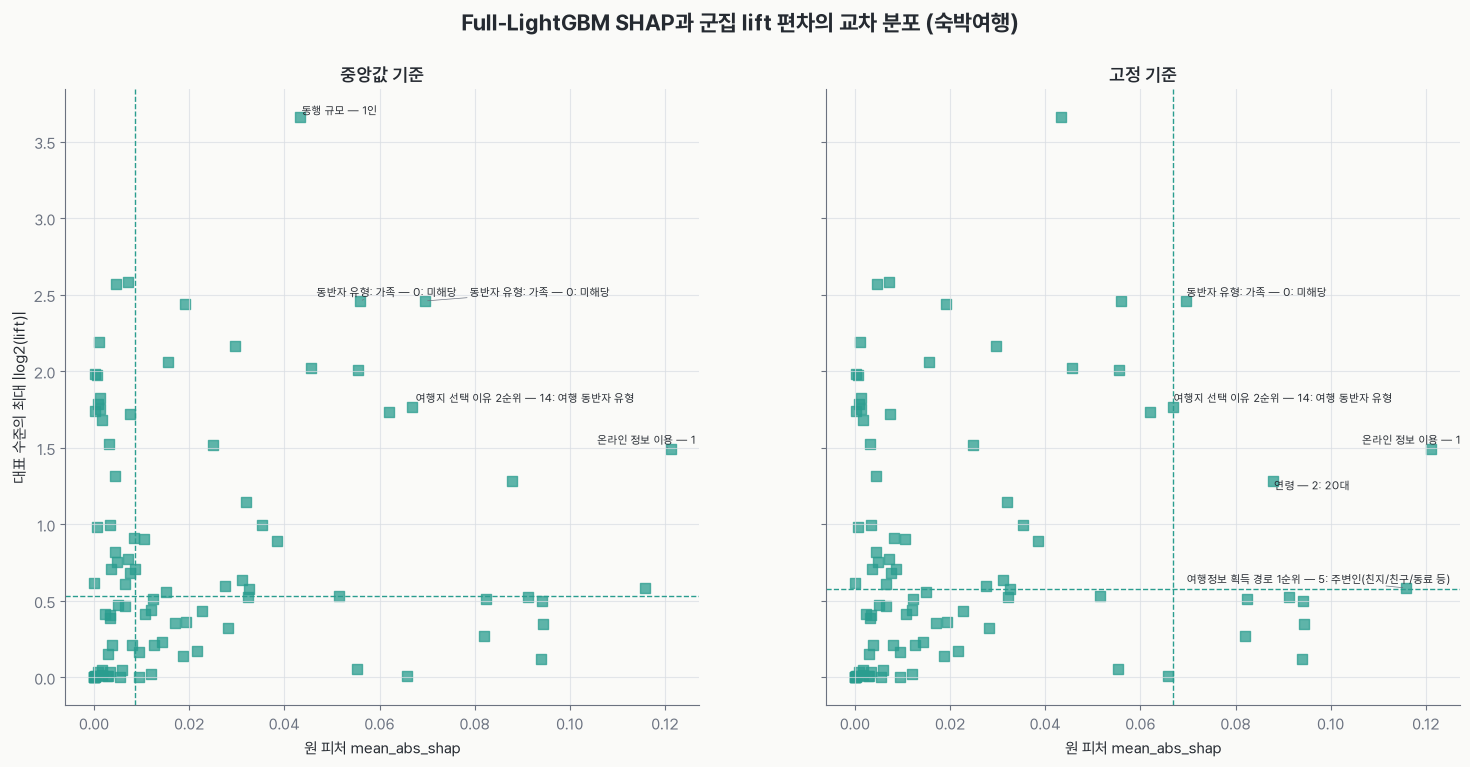

In [38]:
def plot_quadrant_panels(frame: pd.DataFrame) -> None:
    """여행층별로 중앙값과 고정 기준 4분면 산점도를 나란히 저장한다.

    원 피처의 SHAP 중요도는 층에 상관없이 같은 값이 두 층에 그대로
    복제돼 있으므로, 같은 피처가 한 그림 안에서 두 번 찍혀 보이지
    않도록 층마다 별도 그림을 그린다.

    Args:
        frame: 비교 가능한 피처별 여행층 교차근거표다.
    """
    color_map = {
        "당일여행": COLORS["primary"],
        "숙박여행": COLORS["secondary"],
    }
    marker_map = {"당일여행": "o", "숙박여행": "s"}
    fixed_shap_boundary = frame.loc[
        frame["SHAP 상위 20개 여부"], "mean_abs_shap"
    ].min()
    fixed_lift_boundary = min(
        abs(np.log2(FIXED_LIFT_HIGH)),
        abs(np.log2(FIXED_LIFT_LOW)),
    )

    for stratum, stratum_frame in frame.groupby("층", observed=True):
        figure, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
        point_color = color_map.get(stratum, COLORS["neutral"])
        panels = [
            (
                axes[0],
                "중앙값 기준",
                "중앙값_SHAP",
                "중앙값_lift_편차",
            ),
            (
                axes[1],
                "고정 기준",
                "고정_SHAP",
                "고정_lift",
            ),
        ]
        for axis, title, shap_column, lift_column in panels:
            axis.scatter(
                stratum_frame["mean_abs_shap"],
                stratum_frame["최대 lift 편차"],
                color=point_color,
                marker=marker_map.get(stratum, "D"),
                alpha=0.75,
                s=48,
            )
            row = stratum_frame.iloc[0]
            if shap_column == "고정_SHAP":
                x_value = fixed_shap_boundary
                y_value = fixed_lift_boundary
                label_points = stratum_frame.loc[
                    stratum_frame["SHAP 상위 20개 여부"]
                    & stratum_frame["고정 기준 lift 충족"]
                ]
            else:
                x_value = row[shap_column]
                y_value = row[lift_column]
                normalized_shap = stratum_frame["mean_abs_shap"] / (
                    stratum_frame["mean_abs_shap"].max()
                )
                normalized_lift = stratum_frame["최대 lift 편차"] / (
                    stratum_frame["최대 lift 편차"].max()
                )
                corner_distance = np.hypot(
                    normalized_shap - 1,
                    normalized_lift - 1,
                )
                label_points = stratum_frame.loc[
                    corner_distance.nsmallest(5).index
                ]
            axis.axvline(x_value, color=point_color, ls="--", lw=1)
            axis.axhline(y_value, color=point_color, ls="--", lw=1)
            label_texts = [
                axis.text(
                    label_row["mean_abs_shap"],
                    label_row["최대 lift 편차"],
                    label_row["대표 표시 특징"],
                    fontsize=8,
                )
                for _, label_row in label_points.iterrows()
            ]
            adjust_text(
                label_texts,
                ax=axis,
                arrowprops={
                    "arrowstyle": "-",
                    "color": COLORS["neutral"],
                    "lw": 0.5,
                },
            )
            axis.set_title(title)
            axis.set_xlabel("원 피처 mean_abs_shap")
            axis.grid(axis="both")
        axes[0].set_ylabel("대표 수준의 최대 |log2(lift)|")
        figure.suptitle(
            f"Full-LightGBM SHAP과 군집 lift 편차의 교차 분포 ({stratum})",
            y=0.98,
        )
        figure.savefig(
            FIGURES_DIR / f"shap_lift_quadrant_comparison_{stratum}.png",
            dpi=900,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(figure)


plot_quadrant_panels(quadrant_rule_comparison)

## 도메인별 교차해석

도메인 합성점수나 새 모형은 만들지 않는다. Full-LightGBM 도메인 SHAP 순위와
연결 가능한 피처 수, 각 여행층에서 가장 큰 대표 군집 차이의 근거만 함께
기록한다.

In [39]:
shap_domains = shap_domains.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
shap_domains["도메인 SHAP 순위"] = shap_domains.index + 1
comparable_counts = (
    feature_mapping_audit.loc[
        feature_mapping_audit["매칭 분류"].isin(
            ["정의 일치", "검증 별칭"]
        )
    ]
    .groupby("domain", observed=True)["original_feature"]
    .nunique()
    .rename("연결 가능한 피처 수")
    .reset_index()
)
domain_representatives = (
    quadrant_rule_comparison.sort_values(
        ["domain", "층", "최대 lift 편차", "SHAP 순위"],
        ascending=[True, True, False, True],
    )
    .drop_duplicates(["domain", "층"], keep="first")
    .loc[
        :,
        [
            "domain",
            "층",
            "original_feature",
            "대표 표시 특징",
            "대표 군집",
            "대표 수준 라벨",
            "대표 lift",
            "대표 log2(lift)",
            "최대 lift 편차",
        ],
    ]
)
cross_domain_summary = (
    shap_domains.merge(comparable_counts, on="domain", how="left")
    .merge(domain_representatives, on="domain", how="left")
    .rename(
        columns={
            "domain": "도메인",
            "mean_abs_shap": "도메인 mean_abs_shap",
            "original_feature": "대표 근거 SHAP 피처",
        }
    )
    .sort_values(["도메인 SHAP 순위", "층"])
)
cross_domain_summary["연결 가능한 피처 수"] = (
    cross_domain_summary["연결 가능한 피처 수"].fillna(0).astype(int)
)
cross_domain_summary.to_csv(
    TABLES_DIR / "cross_domain_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
display(cross_domain_summary)

,도메인,도메인 mean_abs_shap,도메인 SHAP 순위,연결 가능한 피처 수,층,대표 근거 SHAP 피처,대표 표시 특징,대표 군집,대표 수준 라벨,대표 lift,대표 log2(lift),최대 lift 편차
0,소비,1.655000,1,3,당일여행,spent_a8g,활동비 지출 여부 — 1,당일여행 C1,1,3.952044,1.982599,1.982599
1,소비,1.655000,1,3,숙박여행,spent_a8g,활동비 지출 여부 — 1,숙박여행 C1,1,1.710955,0.774802,0.774802
2,숙박,0.729884,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,동반,0.595720,3,11,당일여행,with_child,미성년자 동반 — 1,당일여행 C1,1,1.744754,0.803024,0.803024
4,동반,0.595720,3,11,숙박여행,party_size_band,동행 규모 — 1인,숙박여행 C2,1인,12.630530,3.658843,3.658843
5,기타,0.547878,4,17,당일여행,A3_RANKW_10,여행지 선택 이유 점수: 체험프로그램,당일여행 C1,가중평균,4.237466,2.083202,2.083202
6,기타,0.547878,4,17,숙박여행,A3_RANKW_10,여행지 선택 이유 점수: 체험프로그램,숙박여행 C2,가중평균,0.184197,-2.440676,2.440676
7,활동,0.476886,5,27,당일여행,A4_7,여행활동: 온천·스파 — 1: 해당,당일여행 C1,해당,5.701594,2.511365,2.511365
8,활동,0.476886,5,27,숙박여행,A4_5,여행활동: 테마파크·동식물원 — 1: 해당,숙박여행 C2,해당,0.401950,-1.314911,1.314911
9,정보,0.382537,6,9,당일여행,A5_2,여행정보 획득 경로 2순위 — 1: 인터넷 사이트/모바일 앱(PC/스마트폰),당일여행 C1,인터넷 사이트/모바일 앱(PC/스마트폰),2.039552,1.028252,1.028252


## 최종 문서 7절에 옮길 수 있는 해석 문안

아래 문안은 저장된 교차근거의 상위 피처명을 자동으로 넣어 둔 초안이다.
군집 차이를 특정 정책의 효과로 해석하지 않으며, 실행 전에는 대표 수준과
N을 `cross_feature_evidence.csv`에서 다시 확인한다.

In [40]:
common_candidates = quadrant_rule_comparison.loc[
    quadrant_rule_comparison["중앙값 기준 4분면"].eq(
        "높은 분류 중요도·큰 군집 차이"
    )
].sort_values(["SHAP 순위", "최대 lift 편차"], ascending=[True, False])
common_names = common_candidates["original_feature"].drop_duplicates().head(3)
common_text = ", ".join(common_names) if len(common_names) else "교차근거 상위 피처"
print(
    "공통 정책 문안: CASE 1·CASE 2 분류에서 중요하고 군집 간 차이도 큰 "
    f"요소({common_text})는 획일적 홍보 대신 여행층·군집별 정보 제공과 "
    "상품 조합을 달리 설계할 우선 점검 축으로 활용한다. 이는 집단별 연관성에 "
    "근거한 제안이며 정책효과의 인과 추정은 아니다."
)
for stratum, subset in common_candidates.groupby("층", observed=True):
    names = ", ".join(subset["original_feature"].drop_duplicates().head(2))
    print(
        f"{stratum} 군집별 정책 문안: {names or '대표 근거 피처'}의 "
        "과대표·과소대표 수준을 확인해 동일 여행층 안에서도 안내 내용과 "
        "연계 서비스를 차등화한다."
    )
print(
    "핵심 정책축 문안: 분류 중요도와 군집 차이를 함께 보되, 정의가 같아 "
    "비교 가능한 변수에만 한정해 우선순위를 정한다. 미매칭·정의 불일치 "
    "피처는 보조 맥락으로만 사용한다."
)

공통 정책 문안: CASE 1·CASE 2 분류에서 중요하고 군집 간 차이도 큰 요소(information_online, A5_1, share_a8f)는 획일적 홍보 대신 여행층·군집별 정보 제공과 상품 조합을 달리 설계할 우선 점검 축으로 활용한다. 이는 집단별 연관성에 근거한 제안이며 정책효과의 인과 추정은 아니다.
당일여행 군집별 정책 문안: information_online, A5_1의 과대표·과소대표 수준을 확인해 동일 여행층 안에서도 안내 내용과 연계 서비스를 차등화한다.
숙박여행 군집별 정책 문안: information_online, A5_1의 과대표·과소대표 수준을 확인해 동일 여행층 안에서도 안내 내용과 연계 서비스를 차등화한다.
핵심 정책축 문안: 분류 중요도와 군집 차이를 함께 보되, 정의가 같아 비교 가능한 변수에만 한정해 우선순위를 정한다. 미매칭·정의 불일치 피처는 보조 맥락으로만 사용한다.


## 한계와 과대해석 방지

- SHAP은 저장된 Full-LightGBM 내부의 평균 절대 기여도이며, 변수의 인과적
  중요도나 정책 개입 효과가 아니다.
- lift는 기존 군집 결과의 가중 상대비율이다. 당일·숙박여행 층을 넘나든
  크기 비교나 응답자 고유 인구 추정으로 바꾸어 해석하지 않는다.
- 대표 수준은 품질 조건을 통과한 후보 중 최대 편차만 보여 주므로, 같은
  변수의 다른 수준과 군집은 원 lift 표에서 함께 검토해야 한다.
- 가족·친지·친구 방문은 조사상 방문 유형이며 출생지·법적 고향을 직접
  측정하지 않는다.
- 고정 기준 민감도는 표시 규칙을 바꾼 결과이지 유의성 검정이 아니다.

In [41]:
print("최종 산출물")
for name in [
    "feature_mapping_audit.csv",
    "cross_feature_evidence.csv",
    "cross_domain_summary.csv",
    "quadrant_rule_comparison.csv",
]:
    print(f"- 표: {TABLES_DIR / name}")
for stratum in ["당일여행", "숙박여행"]:
    print(
        "- 그림: "
        f"{FIGURES_DIR / f'shap_lift_quadrant_comparison_{stratum}.png'}"
    )

from src.notebook_sync import sync_script_from_notebook

sync_script_from_notebook(
    "notebooks/07_Cross/260726_분류_SHAP_군집_lift_교차해석.ipynb"
)

최종 산출물
- 표: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_분류_SHAP_군집_lift_교차해석_260726_1900\tables\feature_mapping_audit.csv
- 표: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_분류_SHAP_군집_lift_교차해석_260726_1900\tables\cross_feature_evidence.csv
- 표: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_분류_SHAP_군집_lift_교차해석_260726_1900\tables\cross_domain_summary.csv
- 표: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_분류_SHAP_군집_lift_교차해석_260726_1900\tables\quadrant_rule_comparison.csv
- 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_분류_SHAP_군집_lift_교차해석_260726_1900\figures\shap_lift_quadrant_comparison_당일여행.png
- 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_분류_SHAP_군집_lift_교차해석_260726_1900\figures\shap_lift_quadrant_comparison_숙박여행.png
생성 스크립트를 노트북 기준으로 만들었습니다: C:\Users\ilove\OneDrive\Desktop\tourism_poster\script\260726_분류_SHAP_군집_lift_교차해석.py


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/script/260726_분류_SHAP_군집_lift_교차해석.py')